In [ ]:
!uv add -r rag-requirements.txt

In [9]:
from langchain_community.document_loaders import PyMuPDFLoader

loader = PyMuPDFLoader("data/real_truth.pdf")
docs = loader.load()
len(docs)

texts = "\n\n".join([doc.page_content for doc in docs])
len(texts)

16759

In [26]:
from langchain_text_splitters import RecursiveCharacterTextSplitter
text_splitter = RecursiveCharacterTextSplitter(chunk_size=800, chunk_overlap=120)
split_docs = text_splitter.split_text(texts)
len(split_docs)

24

In [27]:
from langchain_openai import OpenAIEmbeddings

embeddings = OpenAIEmbeddings()

vectors = embeddings.embed_documents(split_docs)

from sklearn.cluster import KMeans
num_clusters = 10
kmeans = KMeans(n_clusters=num_clusters, random_state=123).fit(vectors)
kmeans.labels_

array([2, 3, 4, 2, 3, 1, 3, 1, 3, 7, 2, 3, 2, 9, 2, 8, 0, 2, 5, 5, 6, 2,
       5, 2], dtype=int32)

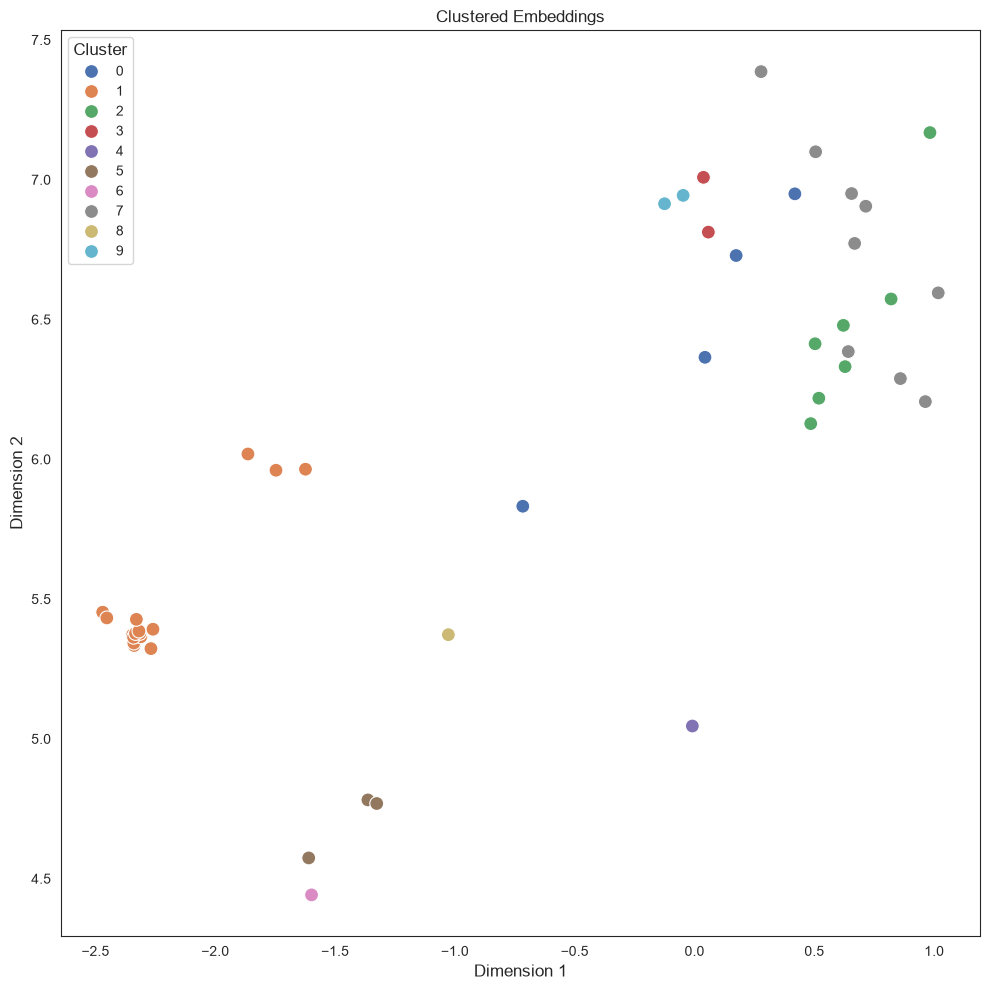

In [16]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings

warnings.filterwarnings("ignore")

tsne = TSNE(n_components=2, random_state=42)
reduced_data_tsne = tsne.fit_transform(np.array(vectors))

sns.set_style("white")

plt.figure(figsize=(10,10))
sns.scatterplot(
    x=reduced_data_tsne[:,0],
    y=reduced_data_tsne[:,1],
    hue = kmeans.labels_,
    palette="deep",
    s=100,
)
plt.xlabel("Dimension 1", fontsize = 12)
plt.ylabel("Dimension 2", fontsize = 12)
plt.title("Clustered Embeddings", fontsize = 12)
plt.legend(title="Cluster", title_fontsize=12)

plt.gcf().patch.set_facecolor("white")

plt.tight_layout()
plt.show()

In [28]:
import numpy as np
closest_indices = []

for i in range(num_clusters):
    distances = np.linalg.norm(vectors - kmeans.cluster_centers_[i], axis=1)
    closest_index = np.argmin(distances)
    closest_indices.append(int(closest_index))

closest_indices

[16, 5, 10, 8, 2, 18, 20, 9, 15, 13]

In [29]:
selected_indices = sorted(closest_indices)
selected_indices

[2, 5, 8, 9, 10, 13, 15, 16, 18, 20]

In [30]:
from langchain_core.documents import Document

selected_docs = [Document(page_content=split_docs[doc]) for doc in selected_indices]
selected_docs

[Document(metadata={}, page_content='A14\n2026-09-27\n李대통령, 순방 귀국길 알래스카서 \'즉석 차담회\'\nA15\n2026-09-27\n[미리보는 국감 2026] 운영위·재경위·행안위 최대 쟁점…인사·부동산·경찰개혁\nA16\n2026-09-28\n정점식 "일도 못하는 무능한 대통령…국민 한숨 이어져"\nA17\n2026-09-28\n국감 앞두고 공세 수위 올리는 野…장외 집회는 \'신중론\'\nA18\n2026-09-28\n나경원 "DMZ 지뢰 폭발사고 진상 조사단, 야당 추천 전문가 포함해야"\nA19\n2026-09-28\n국힘, 영화 \'암살자(들)\'에 "명백한 역사 왜곡"\nA20\n2026-09-29\n정점식, 李 겨냥 "\'공소취소 특검\' 중단하지 않으면 스스로 탄핵의 문 여는 것"\nA21\n2026-09-29\n與, 이르면 내달 초 \'조작기소 특검법\' 처리 검토…野 필리버스터 맞불\n실습 팁: 기사별 article_id, 날짜, 카테고리, 키워드와 source_url을 메타데이터로 저장하면 Metadata Filter, MultiQuery, Ensemble, Pa\nrentDocument 실습을 확장하기 쉽습니다.'),
 Document(metadata={}, page_content='매일일보 조정훈 인턴기자 기사 - RAG/Retriever 실습용 요약\n5\nA03   ARTICLE 03\n[속보] 초대 중수청장 최종 후보에 檢출신 김지용 변호사\n매체: 매일일보   |   작성: 조정훈 인턴기자   |   날짜: 2026-09-07   |   분야: 행정 / 인사\n실습용 핵심 요약\n신설 중대범죄수사청의 초대 청장 최종 후보로 김지용 변호사가 지명됐다는 소식을 전하는 속보다.\n김 후보자가 검찰 출신이라는 점과 초대 기관장 인선이라는 점이 핵심 정보로 제시된다.\n인물명, 기관명, 직책이 명확한 짧은 문서여서 Retriever에서 고유명사 검색 성능을 시험하기 좋다.\n키워드\n중대범

In [34]:
from langsmith import Client
from langchain_openai import ChatOpenAI
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import chain
from langchain_teddynote.callbacks import StreamingCallback

client = Client()

refine_prompt = client.pull_prompt(
    "teddynote/refine-prompt",
    dangerously_pull_public_prompt=True
)

refine_llm = ChatOpenAI(
    temperature=0.1,
    model_name="gpt-4o-mini",
)

refine_chain = refine_prompt | refine_llm | StrOutputParser()

from langchain_core.runnables import chain

@chain
def map_refine_chain(docs):

    map_summary = client.pull_prompt(
        "teddynote/map-summary-prompt",
        dangerously_pull_public_prompt=True
    )

    map_chain = (
        map_summary
        | ChatOpenAI(
            model_name = "gpt-4o-mini",
            temperature=0.1,
        )
        |StrOutputParser()
    )

    input_doc = [{"documents": doc.page_content, "language": "Korean"} for doc in docs]

    doc_summaries = map_chain.batch(input_doc)

    refine_prompt = client.pull_prompt(
        "teddynote/refine-prompt",
        dangerously_pull_public_prompt=True
    )

    refine_llm = ChatOpenAI(
        model_name = "gpt-4o-mini",
        temperature=0.1,
        callbacks = [StreamingCallback()],
        streaming = True,
    )

    refine_chain = refine_prompt | refine_llm | StrOutputParser()

    previous_summary = doc_summaries[0]

    for current_summary in doc_summaries[1:]:
        previous_summary = refine_chain.invoke(
            {
                "previous_summary": previous_summary,
                "current_summary": current_summary,
                "language": "Korean",
            }
        )
        print("\n\n---------------------\n\n")

    return previous_summary

refined_summary = map_refine_chain.invoke(selected_docs)
print(refined_summary)

이 문서는 2026년 9월 27일부터 29일까지의 정치적 사건과 발언들을 다루고 있다. 이재명 대통령은 알래스카에서 즉석 차담회를 가졌으며, 야당은 국정감사에 대비해 공세를 강화하고 있다. 정점식 의원은 대통령의 무능함을 비판하며, 공소취소 특검 중단 시 탄핵 가능성을 언급했다. 나경원 의원은 DMZ 지뢰 폭발사고에 대한 진상 조사단에 야당 추천 전문가 포함을 요구했다. 여당은 '조작기소 특검법' 처리를 검토하고 있으며, 야당은 필리버스터를 준비하고 있다. 또한, 초대 중대범죄수사청장 최종 후보로 김지용 변호사가 지명되었으며, 그는 검찰 출신으로 중대범죄수사청의 첫 기관장 인선이라는 점이 중요하다.

---------------------


이 문서는 2026년 9월 27일부터 29일까지의 정치적 사건과 발언들을 다루고 있다. 이재명 대통령은 알래스카에서 즉석 차담회를 가졌으며, 야당은 국정감사에 대비해 공세를 강화하고 있다. 정점식 의원은 대통령의 무능함을 비판하며, 공소취소 특검 중단 시 탄핵 가능성을 언급했다. 나경원 의원은 DMZ 지뢰 폭발사고에 대한 진상 조사단에 야당 추천 전문가 포함을 요구했다. 여당은 '조작기소 특검법' 처리를 검토하고 있으며, 야당은 필리버스터를 준비하고 있다. 또한, 초대 중대범죄수사청장 최종 후보로 김지용 변호사가 지명되었으며, 그는 검찰 출신으로 중대범죄수사청의 첫 기관장 인선이라는 점이 중요하다. 한편, 국방부는 호르무즈 지역의 현지 상황을 파악하기 위해 조사단을 파견한다고 발표했으며, 이는 파병 여부를 확정짓기 위한 것이 아니라 현지 상황을 확인하기 위한 조사 단계임을 강조했다.

---------------------


이 문서는 2026년 9월 27일부터 29일까지의 정치적 사건과 발언들을 다루고 있다. 이재명 대통령은 알래스카에서 즉석 차담회를 가졌으며, 야당은 국정감사에 대비해 공세를 강화하고 있다. 정점식 의원은 대통령의 무능함을 비판하며, 공소취소 특검 중단 시 탄핵 가능성을 언급했다. 나경원 의원은 DM

In [37]:
@chain
def map_refine_chain(docs):

    map_summary = client.pull_prompt(
        "teddynote/map-summary-prompt",
        dangerously_pull_public_prompt=True
    )

    map_chain = (
        map_summary
        | ChatOpenAI(
            model_name="gpt-4o-mini",
            temperature=0.1,
        )
        | StrOutputParser()
    )

    input_doc = [
        {
            "documents": doc.page_content,
            "language": "Korean"
        }
        for doc in docs
    ]

    doc_summaries = map_chain.batch(input_doc)

    # 여기 추가
    for i, summary in enumerate(doc_summaries):
        print(f"\n===== Map Summary {i} =====")
        print(summary)

    refine_prompt = client.pull_prompt(
        "teddynote/refine-prompt",
        dangerously_pull_public_prompt=True
    )

    refine_llm = ChatOpenAI(
        model_name="gpt-4o-mini",
        temperature=0.1,
    )

    refine_chain = (
        refine_prompt
        | refine_llm
        | StrOutputParser()
    )

    previous_summary = doc_summaries[0]

    for current_summary in doc_summaries[1:]:
        previous_summary = refine_chain.invoke(
            {
                "previous_summary": previous_summary,
                "current_summary": current_summary,
                "language": "Korean",
            }
        )

    return previous_summary


refined_summary = map_refine_chain.invoke(selected_docs)


===== Map Summary 0 =====
- 이 문서는 2026년 9월 27일부터 29일까지의 정치적 사건과 발언들을 다루고 있다.
- 이재명 대통령은 알래스카에서 즉석 차담회를 가졌으며, 야당은 국정감사에 대비해 공세를 강화하고 있다.
- 정점식 의원은 대통령의 무능을 비판하며, 공소취소 특검 중단 시 탄핵 가능성을 언급했다.
- 나경원 의원은 DMZ 지뢰 폭발사고에 대한 진상 조사단에 야당 추천 전문가 포함을 요구했다.
- 여당은 '조작기소 특검법' 처리를 검토하고 있으며, 야당은 필리버스터를 계획하고 있다.

===== Map Summary 1 =====
- 초대 중대범죄수사청의 청장 최종 후보로 김지용 변호사가 지명되었다.
- 김지용 후보자는 검찰 출신으로, 중수청의 첫 기관장 인선이라는 점이 중요하다.
- 이 기사는 인물명, 기관명, 직책이 명확하게 제시되어 있어 검색 성능 테스트에 적합하다.

===== Map Summary 2 =====
- 국방부는 호르무즈 지역의 현지 상황을 파악하기 위해 조사단을 파견한다고 발표했다.
- 이번 발표는 파병 여부를 확정하는 것이 아니라, 현지 상황을 확인하기 위한 조사 단계임을 강조하고 있다.
- 관련 문서들을 통해 '파병 검토', '이란 반응', '조사단 파견' 등 사건의 단계별 내용을 비교할 수 있다.

===== Map Summary 3 =====
- 김민석 더불어민주당 대표가 한동훈 전 국민의힘 대표를 겨냥해 검찰과 정치의 관계를 비판했다.
- 기사에서는 김 대표의 정치적 평가와 주장을 명확히 구분할 필요성이 강조된다.
- '정치 검찰'이라는 표현이 사용되어 검찰의 정치적 역할에 대한 비판이 드러난다.
- 이 문서는 BM25와 의미 검색의 결과 차이를 확인하기에 적합하다.
- 관련 세부 사실과 맥락은 원문 및 1차 자료를 통해 확인해야 한다.

===== Map Summary 4 =====
- 용혜인 후보자가 2026년 9월 13일 오전 11시 30분에 국회에서 기자회견을 열 예정임.
- 이 기사는